In [1]:
library(randomForest) 

ConfusionMatrix <- function(y_pred, y_true) {
  Confusion_Mat <- table(y_true, y_pred)
  return(Confusion_Mat)
}
 
ConfusionDF <- function(y_pred, y_true) {
  Confusion_DF <- transform(as.data.frame(ConfusionMatrix(y_pred, y_true)),
                            y_true = as.character(y_true),
                            y_pred = as.character(y_pred),
                            Freq = as.integer(Freq))
  return(Confusion_DF)
}
 
Precision_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FP <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # it may happen that a label is never predicted (missing from y_pred) but exists in y_true
    # in this case ConfusionDF will not have these lines and thus the simplified code crashes
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]))
   
    # workaround:
    # i don't want to change ConfusionDF since i don't know if the current behaviour is a feature or a bug.
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
   
    tmp <- Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]
    FP[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Precision_micro <- sum(TP) / (sum(TP) + sum(FP))
  return(Precision_micro)
}
 
Recall_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FN <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # short version, comment out due to bug or feature of Confusion_DF
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]))
   
    # workaround:
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
 
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]
    FN[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Recall_micro <- sum(TP) / (sum(TP) + sum(FN))
  return(Recall_micro)
}
 
F1_Score_micro <- function(y_true, y_pred, labels = NULL) {
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred)) # possible problems if labels are missing from y_*
  Precision <- Precision_micro(y_true, y_pred, labels)
  Recall <- Recall_micro(y_true, y_pred, labels)
  F1_Score_micro <- 2 * (Precision * Recall) / (Precision + Recall)
  return(F1_Score_micro)
}

randomForest 4.7-1.1

Type rfNews() to see new features/changes/bug fixes.



In [2]:
datam<-read.csv("data_target_encoding.csv",stringsAsFactors = T)

We use the rfcv function to see how the CV score evolves when removing least important features, with the optimal parameters obtained from randomForestTune.ipynb.

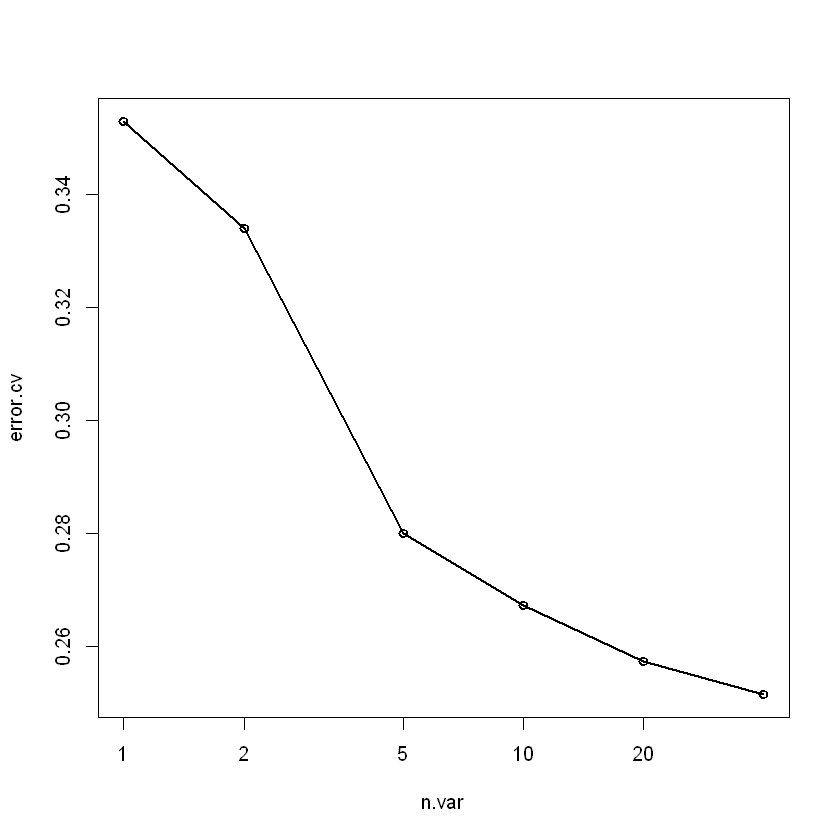

In [5]:
set.seed(2)
n_trees <- 20
datam_idx <- sample(1:nrow(datam))
split <- floor(nrow(datam)*0.8)
target_variable <- ncol(datam)
train_data <- datam[datam_idx[1:split],]
test_data <- datam[datam_idx[(split+1):nrow(datam)],] 

cv_RF<-rfcv(train_data[,-c(target_variable)],as.factor(train_data[,c(target_variable)]),cv.fold=10,ntree=n_trees)

with(cv_RF, plot(n.var, error.cv, log="x", type="o", lwd=2))

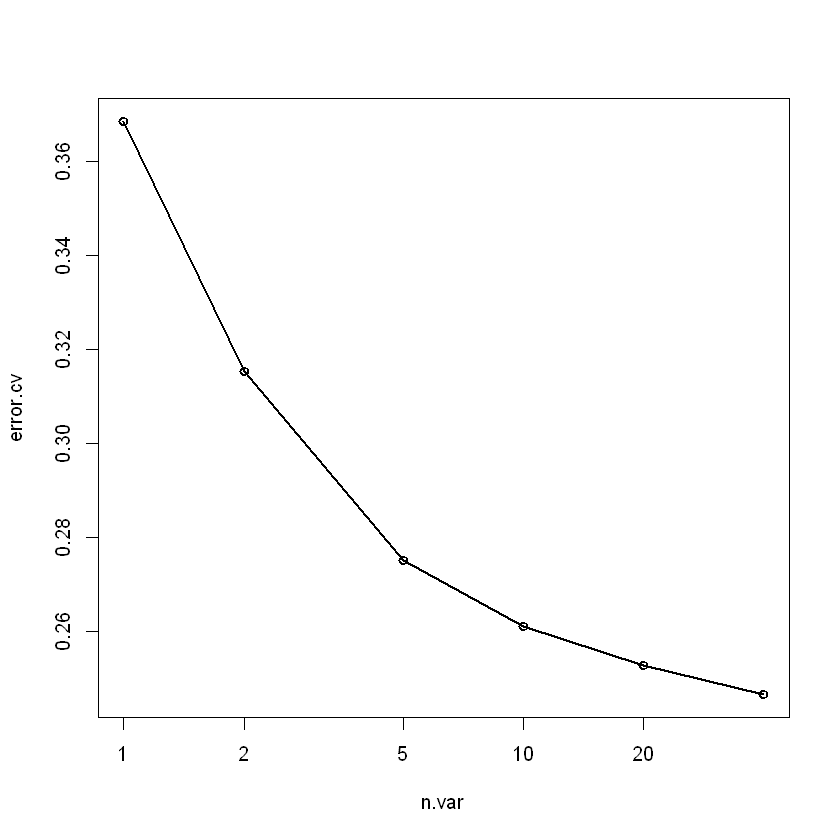

In [6]:
set.seed(2)
n_trees <- 50
datam_idx <- sample(1:nrow(datam))
split <- floor(nrow(datam)*0.8)
target_variable <- ncol(datam)
train_data <- datam[datam_idx[1:split],]
test_data <- datam[datam_idx[(split+1):nrow(datam)],] 

cv_RF<-rfcv(train_data[,-c(target_variable)],as.factor(train_data[,c(target_variable)]),cv.fold=10,ntree=n_trees)

with(cv_RF, plot(n.var, error.cv, log="x", type="o", lwd=2))

In [ ]:
set.seed(2)
n_trees <- 200
datam_idx <- sample(1:nrow(datam))
split <- floor(nrow(datam)*0.8)
target_variable <- ncol(datam)
train_data <- datam[datam_idx[1:split],]
test_data <- datam[datam_idx[(split+1):nrow(datam)],] 

cv_RF<-rfcv(train_data[,-c(target_variable)],as.factor(train_data[,c(target_variable)]),cv.fold=5,ntree=n_trees)

with(cv_RF, plot(n.var, error.cv, log="x", type="o", lwd=2))